# Data Preparation & Model Building

### Predicting Diabetes Risk using the [BRFSS 2015 dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)

Author: Andres Aclan

**Motivation**

1. This notebook prepares the diabetes CSV dataset for machine learning by cleaning the data, inspecting class balance, and verifying there are no missing values. It applies and documents preprocessing steps so the features are reproducible and ready for stratified train-test splitting and model training.
2. Build a Logistic Regression Model and train

**Environment**

No additional packages are required — the `cs171` conda environment includes the necessary libraries (numpy, pandas, matplotlib, scikit-learn, joblib, etc.).

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
import os

# make directories to persist artifacts
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

In [27]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [28]:
counts = df['Diabetes_012'].value_counts().sort_index()

counts.index = counts.index.astype(int)
print("Counts per Diabetes_012 class (0=not diabetic, 1=prediabetic, 2=diabetic):")
print(counts)

Counts per Diabetes_012 class (0=not diabetic, 1=prediabetic, 2=diabetic):
Diabetes_012
0    213703
1      4631
2     35346
Name: count, dtype: int64


This dataset it not balanced. Since there is not enough labels for prediabetic I'll remove them.

In [29]:
# drop prediabetic rows (label == 1) and reset index
df = df[df['Diabetes_012'] != 1].reset_index(drop=True)

# 0=nondiabetic, 1=diabetic
df['Diabetes_012'] = df['Diabetes_012'].replace(2, 1).astype(int)

# check for null values in the dataframe
null_counts = df.isnull().sum()
print("Null counts per column:")
print(null_counts)

total_nulls = null_counts.sum()
print(f"\nTotal null values in dataframe: {total_nulls}")

Null counts per column:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total null values in dataframe: 0


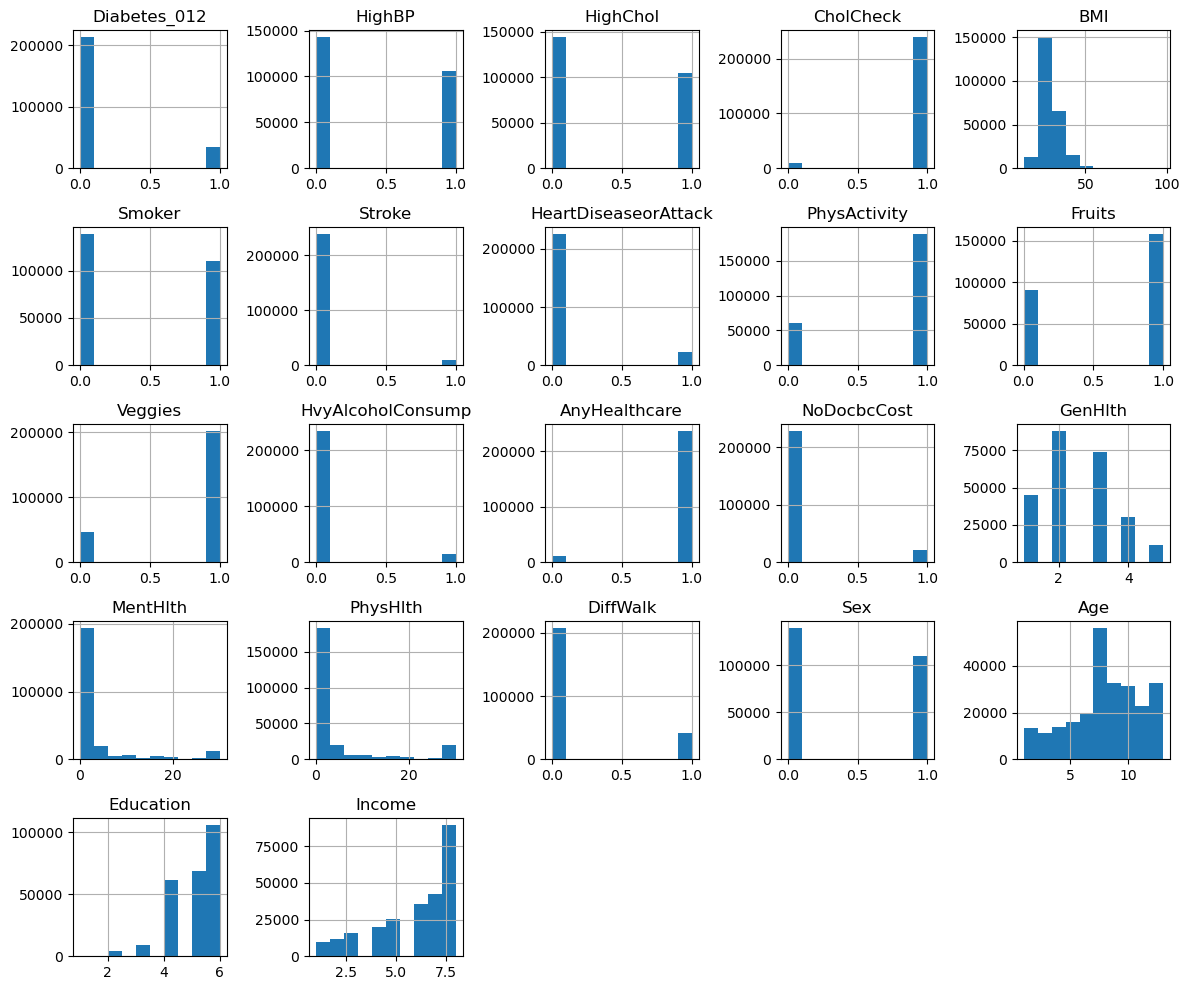

In [30]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

- Dataset looks clean: no missing values (null counts = 0) and all features/target are present.  
- We removed prediabetics and binarized the target so it's ready for supervised modeling.  
- Feature distributions (see histograms) are approximately normal or well-behaved with no obvious pathological skew, making StandardScaler appropriate. (Ignore binary features) 
- A class imbalance still exists (fewer diabetics), but stratified splitting and class-weighting will be applied to mitigate it.

## Building the Model

I went with Logistic Regression for its probabalistic classification strategy. Because diabetes can be predicted by health indicators but it is never 100% accurate given the great amount of variability in human physiology.

In [31]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

It is important to ensure that the data is standardized especially with numerous features in our data. StandardScaler achieves this by standardizing the values in the design matrix so no single feature dominates. Then, a Pipeline combines preprocessing and the model into a single object to ensure transforms are applied consistently.

In [32]:
# features / target
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012'].astype(int)

# stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# pipeline with scaling (class-weighted)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced', # since there are less labels for diabetic compared to not diabetic
        random_state=42))
])

# StratifiedKFold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # fit pipeline on fold
    pipe.fit(X_tr, y_tr)

    # predictions and probs
    y_pred = pipe.predict(X_val)
    y_prob = pipe.predict_proba(X_val)[:, 1]

# train final model on full training set and evaluate on held-out test set
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [33]:
def compute_loss(model, X, y):
    y_pred = model.predict(X)
    loss = np.sum(y_pred != y)  # misclassifications
    loss = loss / len(y)        # normalize by number of samples
    return loss

In [34]:
loss = compute_loss(pipe, X, y)
print(loss)

0.2637272183385599


**~1 in 4 labels are misclassified**

In [35]:
# save trained pipe
import joblib
joblib.dump(pipe, 'models/logreg_pipe.joblib')

# save predictions + probabilities on test data
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]
out = X_test.copy()
out['y_true'] = y_test.values
out['y_pred'] = y_pred
out['y_prob'] = y_prob
out.to_csv('outputs/test_predictions.csv', index=False)